# Analysis - Experiments

In [1]:
# SetUp

import os
import sys

# PROJ_DATA_PATH = "/opt/conda/envs/geospatial/share/proj"
PROJPATH = '/home/jovyan/projetos/proj_amazonia_dggs'
PROJBASEPATH = f'{PROJPATH}/proj_amazonia_dggs_base'

ENVPATH = f'{PROJBASEPATH}/env/proj_amazonia_dggs'
SRCPATH = f'{PROJBASEPATH}/src'

LOCALPATH = f'{PROJPATH}/amazonia_dggs_accuracy_experiments'
DATAPATH = f'{LOCALPATH}/data'
DOCPATH = f'{LOCALPATH}/docs'
LOCALSRCPATH = f'{LOCALPATH}/src'

os.environ['PROJ_DATA'] = f'{ENVPATH}/share/proj'
sys.path.append(SRCPATH)
sys.path.append(LOCALSRCPATH)

In [2]:
# Packages

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import stats
from tqdm.notebook import tqdm

# Local packages

import analysis
import area_definitions


In [3]:
input_folder = f'{DATAPATH}/processed/experiments'
fig_output_folder =  f'{DOCPATH}/eda_experiments'

### Reading data

In [4]:
# Experiment 1
## IVEA7H

ivea7h_f1h1 = gpd.read_parquet(
    f'{input_folder}/IVEA7H_f1h1.parquet')

ivea7h_f1h2 = gpd.read_parquet(
    f'{input_folder}/IVEA7H_f1h2.parquet')

## rHEALPix-3N

rhealpix_f1h1 = gpd.read_parquet(
    f'{input_folder}/rHEALPix_f1h1.parquet')

rhealpix_f1h2 = gpd.read_parquet(
    f'{input_folder}/rHEALPix_f1h2.parquet')

In [5]:
# Experiment 2
## IVEA7H

ivea7h_f2h1 = gpd.read_parquet(
    f'{input_folder}/IVEA7H_f2h1.parquet')

ivea7h_f2h2 = gpd.read_parquet(
    f'{input_folder}/IVEA7H_f2h2.parquet')

## rHEALPix-3N

rhealpix_f2h1 = gpd.read_parquet(
    f'{input_folder}/rHEALPix_f2h1.parquet')

rhealpix_f2h2 = gpd.read_parquet(
    f'{input_folder}/rHEALPix_f2h2.parquet')



### Computing Metrics

### Experiment 1

In [6]:
col_names_f1h1 = list(ivea7h_f1h1.filter(regex='^area_').columns.values)
col_names_f1h2 = list(ivea7h_f1h2.filter(regex='^area_').columns.values)
col_names_f2h1 = list(ivea7h_f2h1.filter(regex='^area_').columns.values)
col_names_f2h2 = list(ivea7h_f2h2.filter(regex='^area_').columns.values)


In [7]:
rmse_f1h1_ivea7h, low_ic_f1h1_ivea7h, high_ic_f1h1_ivea7h = analysis.get_rmse(
    exp_data=ivea7h_f1h1,
    col_names=col_names_f1h1,
)

rmse_f1h2_ivea7h, low_ic_f1h2_ivea7h, high_ic_f1h2_ivea7h = analysis.get_rmse(
    exp_data=ivea7h_f1h2,
    col_names=col_names_f1h2,
)


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

In [8]:
rmse_f1h1_rhealpix, low_ic_f1h1_rhealpix, high_ic_f1h1_rhealpix = analysis.get_rmse(
    exp_data=rhealpix_f1h1,
    col_names=col_names_f1h1,
)

rmse_f1h2_rhealpix, low_ic_f1h2_rhealpix, high_ic_f1h2_rhealpix = analysis.get_rmse(
    exp_data=rhealpix_f1h2,
    col_names=col_names_f1h2,
)


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

### Experiment 2

In [9]:
rmse_f2h1_ivea7h, low_ic_f2h1_ivea7h, high_ic_f2h1_ivea7h = analysis.get_rmse(
    exp_data=ivea7h_f2h1,
    col_names=col_names_f2h1,
)

rmse_f2h2_ivea7h, low_ic_f2h2_ivea7h, high_ic_f2h2_ivea7h = analysis.get_rmse(
    exp_data=ivea7h_f2h2,
    col_names=col_names_f2h2,
)


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

In [10]:
rmse_f2h1_rhealpix, low_ic_f2h1_rhealpix, high_ic_f2h1_rhealpix = analysis.get_rmse(
    exp_data=rhealpix_f2h1,
    col_names=col_names_f2h1,
)

rmse_f2h2_rhealpix, low_ic_f2h2_rhealpix, high_ic_f2h2_rhealpix = analysis.get_rmse(
    exp_data=rhealpix_f2h2,
    col_names=col_names_f2h2,
)


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

### Summary plot

/tmp/ipykernel_14140/2320737808.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks)


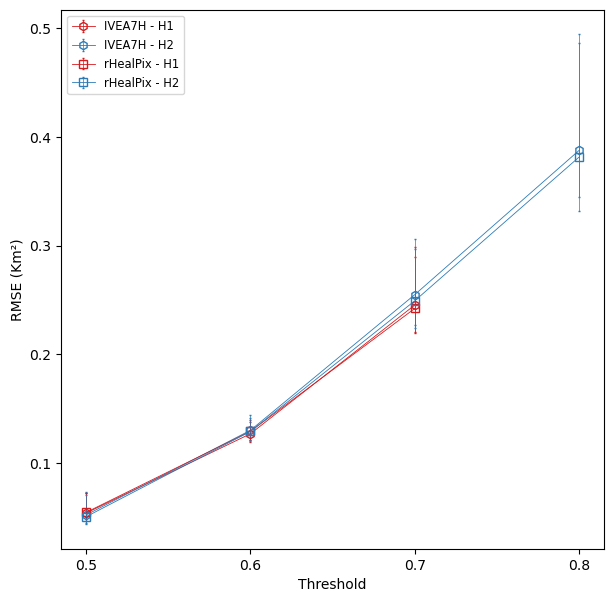

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))


# P1
# IVEA7H
error_f1h1_ivea7h = [np.asarray(rmse_f1h1_ivea7h) - np.asarray(low_ic_f1h1_ivea7h),
                   np.asarray(high_ic_f1h1_ivea7h) - np.asarray(rmse_f1h1_ivea7h)]


ax.errorbar(x=col_names_f1h1, y=rmse_f1h1_ivea7h,
            yerr=error_f1h1_ivea7h, linewidth=0.6, marker='h',
            markerfacecolor='none',color='#d7191c', elinewidth=0.5, capsize=1,
            label='IVEA7H - H1')


error_f1h2_ivea7h = [np.asarray(rmse_f1h2_ivea7h) - np.asarray(low_ic_f1h2_ivea7h),
                   np.asarray(high_ic_f1h2_ivea7h) - np.asarray(rmse_f1h2_ivea7h)]


ax.errorbar(x=col_names_f1h2, y=rmse_f1h2_ivea7h,
            yerr=error_f1h2_ivea7h, linewidth=0.6, marker='h',
            markerfacecolor='none',color='#2c7bb6', elinewidth=0.5, capsize=1,
            label='IVEA7H - H2')

# P1

# rhealpix9

error_f1h1_rhealpix = [np.asarray(rmse_f1h1_rhealpix) - np.asarray(low_ic_f1h1_rhealpix),
                   np.asarray(high_ic_f1h1_rhealpix) - np.asarray(rmse_f1h1_rhealpix)]


ax.errorbar(x=col_names_f1h1, y=rmse_f1h1_rhealpix,
            yerr=error_f1h1_rhealpix, linewidth=0.6, marker='s',
            markerfacecolor='none',color='#d7191c', elinewidth=0.5, capsize=1,
            label='rHealPix - H1')


error_f1h2_rhealpix = [np.asarray(rmse_f1h2_rhealpix) - np.asarray(low_ic_f1h2_rhealpix),
                   np.asarray(high_ic_f1h2_rhealpix) - np.asarray(rmse_f1h2_rhealpix)]


ax.errorbar(x=col_names_f1h2, y=rmse_f1h2_rhealpix,
            yerr=error_f1h2_rhealpix, linewidth=0.6, marker='s',
            markerfacecolor='none',color='#2c7bb6', elinewidth=0.5, capsize=1,
            label='rHealPix - H2')



xticks = [col_name.split('_')[1] for col_name in col_names_f2h2]
ax.set_xticklabels(xticks)


ax.set_xlabel('Threshold')
ax.set_ylabel('RMSE (Km²)')
ax.legend(fontsize='small', loc='upper left')


plt.savefig(f'{fig_output_folder}/area_error_summary_f1.png', dpi=600)

/tmp/ipykernel_14140/2703603542.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks)


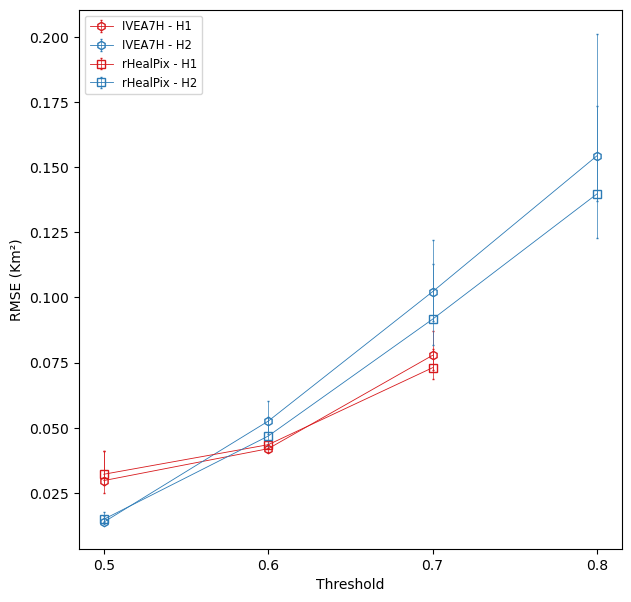

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))


# P2
# IVEA7H
error_f2h1_ivea7h = [np.asarray(rmse_f2h1_ivea7h) - np.asarray(low_ic_f2h1_ivea7h),
                   np.asarray(high_ic_f2h1_ivea7h) - np.asarray(rmse_f2h1_ivea7h)]


ax.errorbar(x=col_names_f2h1, y=rmse_f2h1_ivea7h,
            yerr=error_f2h1_ivea7h, linewidth=0.6, marker='h',
            markerfacecolor='none',color='#d7191c', elinewidth=0.5, capsize=1,
            label='IVEA7H - H1')


error_f2h2_ivea7h = [np.asarray(rmse_f2h2_ivea7h) - np.asarray(low_ic_f2h2_ivea7h),
                   np.asarray(high_ic_f2h2_ivea7h) - np.asarray(rmse_f2h2_ivea7h)]


ax.errorbar(x=col_names_f2h2, y=rmse_f2h2_ivea7h,
            yerr=error_f2h2_ivea7h, linewidth=0.6, marker='h',
            markerfacecolor='none',color='#2c7bb6', elinewidth=0.5, capsize=1,
            label='IVEA7H - H2')

# P1

# rhealpix9

error_f2h1_rhealpix = [np.asarray(rmse_f2h1_rhealpix) - np.asarray(low_ic_f2h1_rhealpix),
                   np.asarray(high_ic_f2h1_rhealpix) - np.asarray(rmse_f2h1_rhealpix)]


ax.errorbar(x=col_names_f2h1, y=rmse_f2h1_rhealpix,
            yerr=error_f2h1_rhealpix, linewidth=0.6, marker='s',
            markerfacecolor='none',color='#d7191c', elinewidth=0.5, capsize=1,
            label='rHealPix - H1')


error_f2h2_rhealpix = [np.asarray(rmse_f2h2_rhealpix) - np.asarray(low_ic_f2h2_rhealpix),
                   np.asarray(high_ic_f2h2_rhealpix) - np.asarray(rmse_f2h2_rhealpix)]


ax.errorbar(x=col_names_f2h2, y=rmse_f2h2_rhealpix,
            yerr=error_f2h2_rhealpix, linewidth=0.6, marker='s',
            markerfacecolor='none',color='#2c7bb6', elinewidth=0.5, capsize=1,
            label='rHealPix - H2')



# xticks = [col_name.split('_')[1] for col_name in col_names_f2h2]
ax.set_xticklabels(xticks)


ax.set_xlabel('Threshold')
ax.set_ylabel('RMSE (Km²)')
ax.legend(fontsize='small', loc='upper left')


plt.savefig(f'{fig_output_folder}/area_error_summary_f2.png', dpi=600)

### Shape metrics - rHealPix

In [13]:
bins = area_definitions.FILTERED_BINS
categories = area_definitions.FILTERED_CATEGORIES

In [14]:
shape_metric_name = 'ba'

In [15]:
rhealpix_f1h2['category'] = pd.cut(rhealpix_f1h2['area'], bins=bins, labels=categories)   

rel_error_f1h2_rhealpix, shape_metric_f1h2_rhealpix, n_f1h2_rhealpix = analysis.get_rel_error_shape_metrics(
    exp_data=rhealpix_f1h2,
    categories=categories,
    threshold='0.5',
    shape_metric_name=shape_metric_name,
)

In [16]:
rhealpix_f2h1['category'] = pd.cut(rhealpix_f2h1['area'], bins=bins, labels=categories)   

rel_error_f2h1_rhealpix, shape_metric_f2h1_rhealpix, n_f2h1_rhealpix = analysis.get_rel_error_shape_metrics(
    exp_data=rhealpix_f2h1,
    categories=categories,
    threshold='0.5',
    shape_metric_name=shape_metric_name,
)

In [17]:
rhealpix_f2h2['category'] = pd.cut(rhealpix_f2h2['area'], bins=bins, labels=categories)   

rel_error_f2h2_rhealpix, shape_metric_f2h2_rhealpix, n_f2h2_rhealpix = analysis.get_rel_error_shape_metrics(
    exp_data=rhealpix_f2h2,
    categories=categories,
    threshold='0.5',
    shape_metric_name=shape_metric_name,
)

In [18]:
ivea7h_f2h2['category'] = pd.cut(ivea7h_f2h2['area'], bins=bins, labels=categories)

rel_error_f2h2_ivea7h, shape_metric_f2h2_ivea7h, n_f2h2_ivea7h = analysis.get_rel_error_shape_metrics(
    exp_data=ivea7h_f2h2,
    categories=categories,
    threshold='0.5',
    shape_metric_name=shape_metric_name,
)

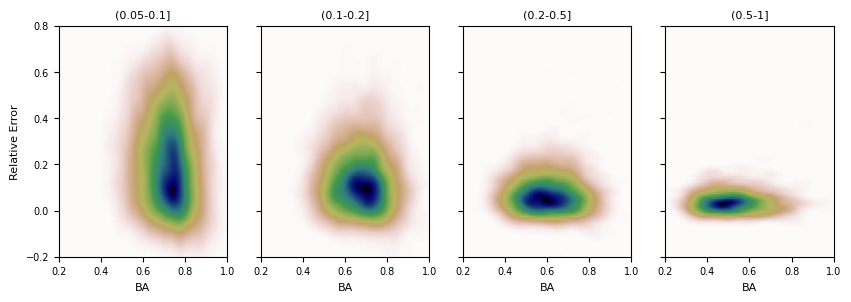

In [19]:
fig, ax = plt.subplots(ncols=4, figsize=(10, 3), sharey=True)

for i in range(4):
    m1, m2 = shape_metric_f2h1_rhealpix[i],  rel_error_f2h1_rhealpix[i]
    
    # xmin = m1.min()
    # xmax = m1.max()
    # ymin = m2.min()
    # ymax = m2.max()

    xmin = 0.2
    xmax = 1
    ymin = -0.2
    ymax = 0.8
    
    values = np.stack([m1, m2])
    kernel = stats.gaussian_kde(values)
    
    X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kernel(positions).T, X.shape)

    ax[i].imshow(np.rot90(Z), cmap=plt.cm.gist_earth_r,
              extent=[xmin, xmax, ymin, ymax], aspect='auto')
    ax[i].set_xlabel('BA', fontsize=8)
    ax[i].set_title(f'{categories[i]}', fontsize=8)
    ax[i].tick_params(labelsize=7)
    
    # ax.plot(m1, m2, 'k.', markersize=2)
    # ax[i].set_xlim([xmin, xmax])
    # ax[i].set_ylim([ymin, ymax])
    
    # ax[1].set_xlim([xmin, xmax])
    # ax[1].set_ylim([ymin, ymax])

ax[0].set_ylabel('Relative Error', fontsize=8)

plt.savefig(f'{fig_output_folder}/rhealpix_ba_f2h1.png', dpi=600)

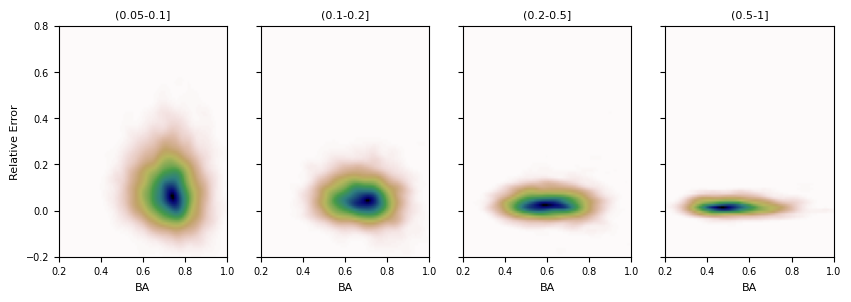

In [20]:
fig, ax = plt.subplots(ncols=4, figsize=(10, 3), sharey=True)

for i in range(4):
    m1, m2 = shape_metric_f2h2_rhealpix[i],  rel_error_f2h2_rhealpix[i]
    
    # xmin = m1.min()
    # xmax = m1.max()
    # ymin = m2.min()
    # ymax = m2.max()

    xmin = 0.2
    xmax = 1
    ymin = -0.2
    ymax = 0.8
    
    values = np.stack([m1, m2])
    kernel = stats.gaussian_kde(values)
    
    X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kernel(positions).T, X.shape)

    ax[i].imshow(np.rot90(Z), cmap=plt.cm.gist_earth_r,
                  extent=[xmin, xmax, ymin, ymax], aspect='auto')
    ax[i].set_xlabel('BA', fontsize=8)
    ax[i].set_title(f'{categories[i]}', fontsize=8)
    ax[i].tick_params(labelsize=7)
    # ax.plot(m1, m2, 'k.', markersize=2)
    # ax[i].set_xlim([xmin, xmax])
    # ax[i].set_ylim([ymin, ymax])
    
    # ax[1].set_xlim([xmin, xmax])
    # ax[1].set_ylim([ymin, ymax])

ax[0].set_ylabel('Relative Error', fontsize=8)

plt.savefig(f'{fig_output_folder}/rhealpix_ba_f2h2.png', dpi=600)

MDIC

In [21]:
shape_metric_name = 'micd'

In [22]:
rhealpix_f2h2['category'] = pd.cut(rhealpix_f2h2['area'], bins=bins, labels=categories)   

rel_error_f2h2_rhealpix, shape_metric_f2h2_rhealpix, n_f2h2_rhealpix = analysis.get_rel_error_shape_metrics(
    exp_data=rhealpix_f2h2,
    categories=categories,
    threshold='0.5',
    shape_metric_name=shape_metric_name
)

In [23]:
rhealpix_f2h1['category'] = pd.cut(rhealpix_f2h1['area'], bins=bins, labels=categories)   

rel_error_f2h1_rhealpix, shape_metric_f2h1_rhealpix, n_f2h1_rhealpix = analysis.get_rel_error_shape_metrics(
    exp_data=rhealpix_f2h1,
    categories=categories,
    threshold='0.5',
    shape_metric_name=shape_metric_name
)

In [24]:
# exp_2a_ivea7h['category'] = pd.cut(exp_2a_ivea7h['area'], bins=bins, labels=categories)
# shape_metric_name = 'mbcr'


# rel_error_exp_2a_ivea7h, shape_metric_exp_2a_ivea7h, n_exp_2a_ivea7h =  get_rel_error_shape_metrics(
#     exp_data=exp_2a_ivea7h,
#     categories=categories,
#     threshold='0.5',
#     shape_metric_name='mbcr'
# )

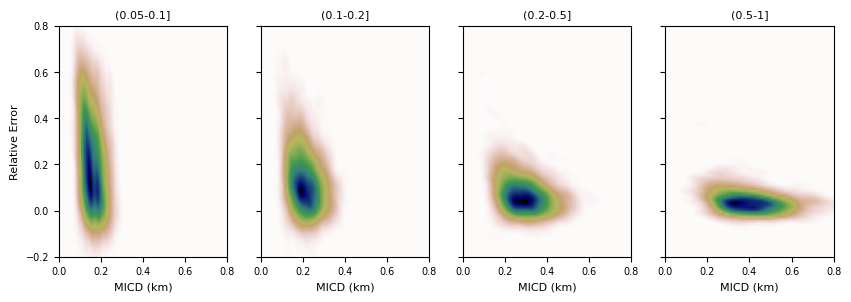

In [25]:
fig, ax = plt.subplots(ncols=4, figsize=(10, 3), sharey=True)

for i in range(4):
    m1, m2 = shape_metric_f2h1_rhealpix[i],  rel_error_f2h1_rhealpix[i]
    
    # xmin = m1.min()
    # xmax = m1.max()
    # ymin = m2.min()
    # ymax = m2.max()

    xmin = 0
    xmax = 0.8
    ymin = -0.2
    ymax = 0.8
    
    values = np.stack([m1, m2])
    kernel = stats.gaussian_kde(values)
    
    X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kernel(positions).T, X.shape)

    ax[i].imshow(np.rot90(Z), cmap=plt.cm.gist_earth_r,
              extent=[xmin, xmax, ymin, ymax], aspect='auto')
    ax[i].set_xlabel('MICD (km)', fontsize=8)
    ax[i].set_title(f'{categories[i]}', fontsize=8)
    ax[i].tick_params(labelsize=7)
    
    # ax.plot(m1, m2, 'k.', markersize=2)
    # ax[i].set_xlim([xmin, xmax])
    # ax[i].set_ylim([ymin, ymax])
    
    # ax[1].set_xlim([xmin, xmax])
    # ax[1].set_ylim([ymin, ymax])

ax[0].set_ylabel('Relative Error', fontsize=8)

plt.savefig(f'{fig_output_folder}/rhealpix_micd_f2h1.png', dpi=600)

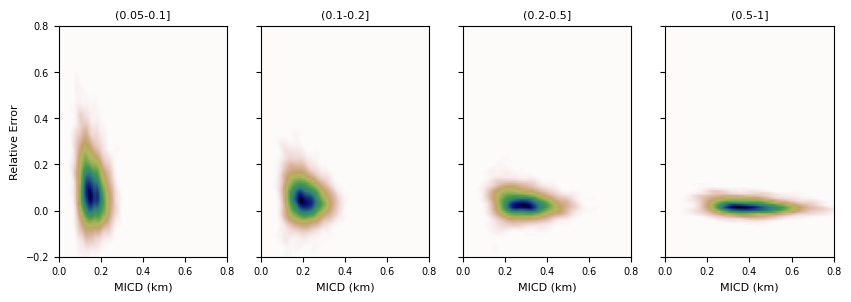

In [26]:
fig, ax = plt.subplots(ncols=4, figsize=(10, 3), sharey=True)

for i in range(4):
    m1, m2 = shape_metric_f2h2_rhealpix[i],  rel_error_f2h2_rhealpix[i]
    
    # xmin = m1.min()
    # xmax = m1.max()
    # ymin = m2.min()
    # ymax = m2.max()

    xmin = 0
    xmax = 0.8
    ymin = -0.2
    ymax = 0.8
    
    values = np.stack([m1, m2])
    kernel = stats.gaussian_kde(values)
    
    X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kernel(positions).T, X.shape)

    ax[i].imshow(np.rot90(Z), cmap=plt.cm.gist_earth_r,
                  extent=[xmin, xmax, ymin, ymax], aspect='auto')
    ax[i].set_xlabel('MICD (km)', fontsize=8)
    ax[i].set_title(f'{categories[i]}', fontsize=8)
    ax[i].tick_params(labelsize=7)
    # ax.plot(m1, m2, 'k.', markersize=2)
    # ax[i].set_xlim([xmin, xmax])
    # ax[i].set_ylim([ymin, ymax])
    
    # ax[1].set_xlim([xmin, xmax])
    # ax[1].set_ylim([ymin, ymax])

ax[0].set_ylabel('Relative Error', fontsize=8)

plt.savefig(f'{fig_output_folder}/rhealpix_micd_f2h2.png', dpi=600)

## Relative Errors

### rHEALPix - Scenarios F1H2 and F2H2 

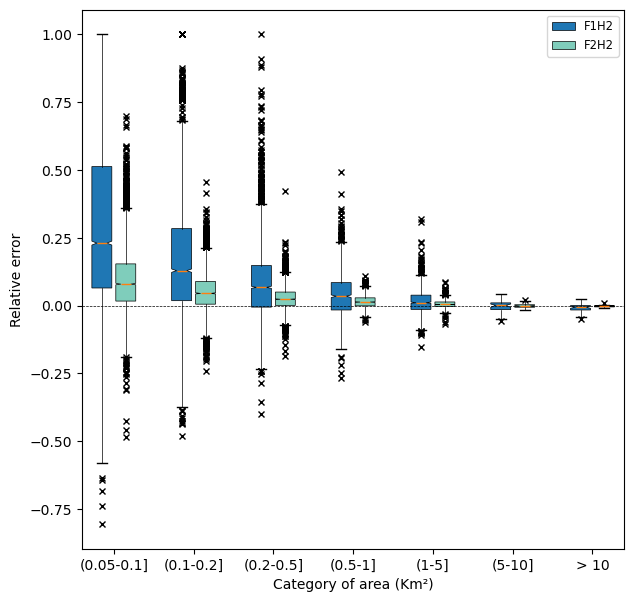

In [27]:
positions = np.linspace(1, 13, 7)

fig, ax = plt.subplots(figsize=(7, 7))



ax.boxplot(rel_error_f1h2_rhealpix,
           positions=positions-0.30,
           sym='x',
           notch=True,
           bootstrap=1000,
           patch_artist=True,
           boxprops=dict(linewidth=0.5),
           whiskerprops=dict(linewidth=0.5),
           flierprops=dict(linewidth=0.5, markersize=5),
           label='F1H2')


ax.boxplot(rel_error_f2h2_rhealpix,
           positions=positions+0.30,
           sym='x',
           notch=True,
           bootstrap=1000,
           patch_artist=True,
           boxprops=dict(facecolor='#7fcdbb', linewidth=0.5),
           whiskerprops=dict(linewidth=0.5),
           flierprops=dict(linewidth=0.5, markersize=5),
           label='F2H2')

ax.axhline(y=0, linewidth=0.5, linestyle='dashed', color='black')

ax.legend(fontsize='small')
ax.set_xticks(positions)
ax.set_xticklabels(categories)
ax.set_ylabel('Relative error')
ax.set_xlabel('Category of area (Km²)')



plt.savefig(f'{fig_output_folder}/rhealpix_rel_error_f1h2_f2h2.png', dpi=600)

### rHEALPix - Scenarios F2H1 and F2H2 

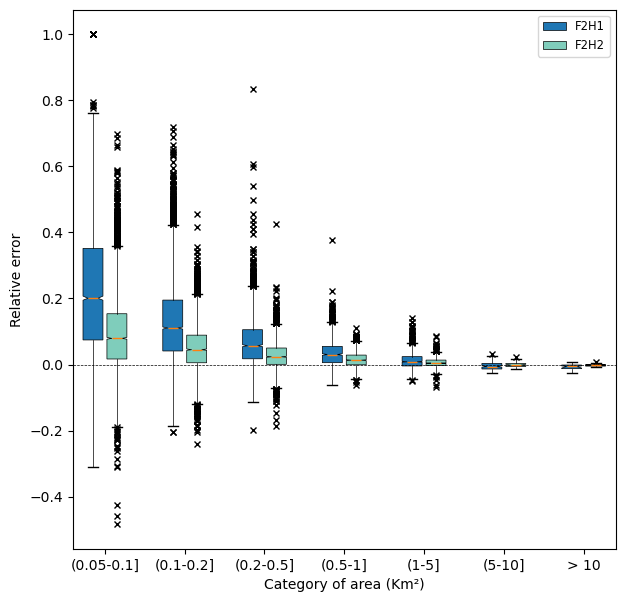

In [28]:
positions = np.linspace(1, 13, 7)

fig, ax = plt.subplots(figsize=(7, 7))



ax.boxplot(rel_error_f2h1_rhealpix,
           positions=positions-0.30,
           sym='x',
           notch=True,
           bootstrap=1000,
           patch_artist=True,
           boxprops=dict(linewidth=0.5),
           whiskerprops=dict(linewidth=0.5),
           flierprops=dict(linewidth=0.5, markersize=5),
           label='F2H1')


ax.boxplot(rel_error_f2h2_rhealpix,
           positions=positions+0.30,
           sym='x',
           notch=True,
           bootstrap=1000,
           patch_artist=True,
           boxprops=dict(facecolor='#7fcdbb', linewidth=0.5),
           whiskerprops=dict(linewidth=0.5),
           flierprops=dict(linewidth=0.5, markersize=5),
           label='F2H2')

ax.axhline(y=0, linewidth=0.5, linestyle='dashed', color='black')

ax.legend(fontsize='small')
ax.set_xticks(positions)
ax.set_xticklabels(categories)
ax.set_ylabel('Relative error')
ax.set_xlabel('Category of area (Km²)')



plt.savefig(f'{fig_output_folder}/rhealpix_rel_error_f2h1_f2h2.png', dpi=600)

###  rHEALPix x IVEA7H - scenario F2H2

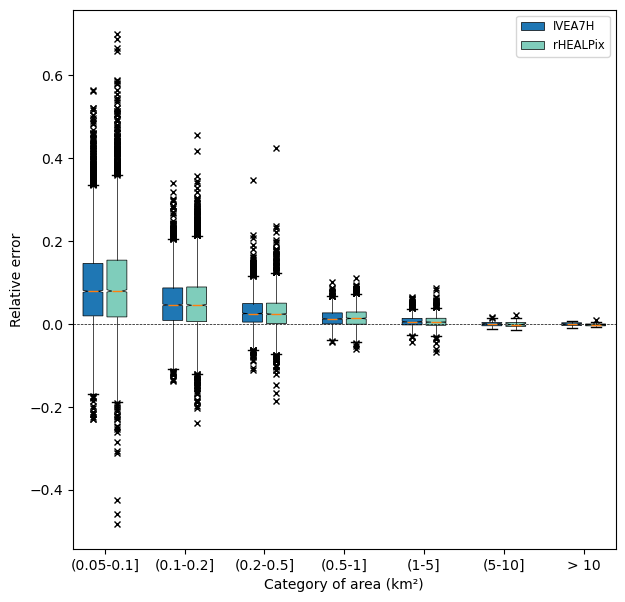

In [29]:
positions = np.linspace(1, 13, 7)

fig, ax = plt.subplots(figsize=(7, 7))



ax.boxplot(rel_error_f2h2_ivea7h,
           positions=positions-0.30,
           sym='x',
           notch=True,
           bootstrap=1000,
           patch_artist=True,
           boxprops=dict(linewidth=0.5),
           whiskerprops=dict(linewidth=0.5),
           flierprops=dict(linewidth=0.5, markersize=5),
           label='IVEA7H')


ax.boxplot(rel_error_f2h2_rhealpix,
           positions=positions+0.30,
           sym='x',
           notch=True,
           bootstrap=1000,
           patch_artist=True,
           boxprops=dict(facecolor='#7fcdbb', linewidth=0.5),
           whiskerprops=dict(linewidth=0.5),
           flierprops=dict(linewidth=0.5, markersize=5),
           label='rHEALPix')

ax.axhline(y=0, linewidth=0.5, linestyle='dashed', color='black')

ax.legend(fontsize='small')
ax.set_xticks(positions)
ax.set_xticklabels(categories)
ax.set_ylabel('Relative error')
ax.set_xlabel('Category of area (km²)')



plt.savefig(f'{fig_output_folder}/ivea_rhealpix_rel_error_f2h2.png', dpi=600)

In [30]:
log_n_f2h2_ivea7h = [np.log2(s + 0.1) for s in n_f2h2_ivea7h]
log_n_f2h2_rhealpix = [np.log2(s + 0.1) for s in n_f2h2_rhealpix]


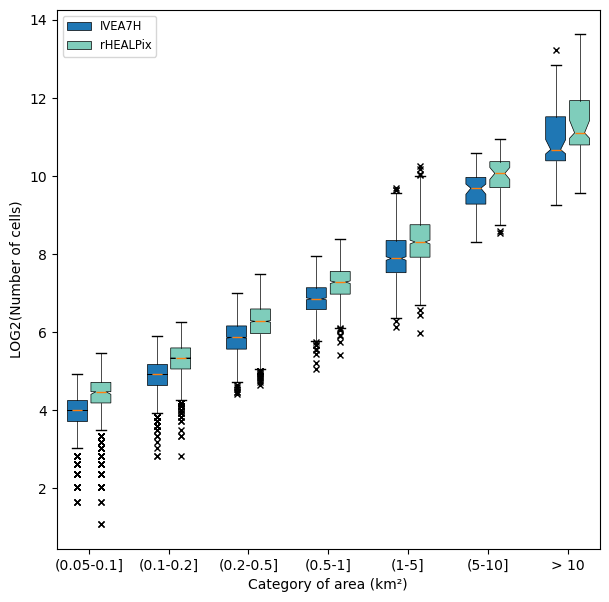

In [31]:
positions = np.linspace(1, 13, 7)

fig, ax = plt.subplots(figsize=(7, 7))



ax.boxplot(log_n_f2h2_ivea7h,
           positions=positions-0.30,
           sym='x',
           notch=True,
           bootstrap=1000,
           patch_artist=True,
           boxprops=dict(linewidth=0.5),
           whiskerprops=dict(linewidth=0.5),
           flierprops=dict(linewidth=0.5, markersize=5),
           label='IVEA7H')


ax.boxplot(log_n_f2h2_rhealpix,
           positions=positions+0.30,
           sym='x',
           notch=True,
           bootstrap=1000,
           patch_artist=True,
           boxprops=dict(facecolor='#7fcdbb', linewidth=0.5),
           whiskerprops=dict(linewidth=0.5),
           flierprops=dict(linewidth=0.5, markersize=5),
           label='rHEALPix')

# ax.axhline(y=0, linewidth=0.5, linestyle='dashed', color='black')

ax.legend(fontsize='small')
ax.set_xticks(positions)
ax.set_xticklabels(categories)
ax.set_ylabel('LOG2(Number of cells)')
ax.set_xlabel('Category of area (km²)')

plt.savefig(f'{fig_output_folder}/ivea_rhealpix_cell_number_f2h2.png', dpi=600)

## Tempo de execução

In [32]:
# times_exp['category'] = pd.cut(times_exp['area'], bins=bins, labels=categories)   

# times_exp['log_time_ivea7h'] = np.log2(times_exp['time_ivea7h'])
# times_exp['log_time_rhealpix_dggal'] = np.log2(times_exp['time_rhealpix_dggal'])
# times_exp['log_time_rhealpix'] = np.log2(times_exp['time_rhealpix'])

# times_ivea7h = []
# times_rhealpix_dggal = []
# times_rhealpix = []

# for cat in categories:
#     tmp = times_exp.loc[times_exp.category == cat]
#     times_ivea7h.append(tmp['log_time_ivea7h'].values)
#     times_rhealpix_dggal.append(tmp['log_time_rhealpix_dggal'].values)
#     times_rhealpix.append(tmp['log_time_rhealpix'].values)


In [33]:
# positions = np.linspace(1, 13, 7)

# fig, ax = plt.subplots(figsize=(7, 7))



# ax.boxplot(times_ivea7h,
#            positions=positions-0.60,
#            sym='x',
#            notch=True,
#            bootstrap=1000,
#            patch_artist=True,
#            boxprops=dict(linewidth=0.5),
#            whiskerprops=dict(linewidth=0.5),
#            flierprops=dict(linewidth=0.5, markersize=5),
#            label='IVEA7H')

# ax.boxplot(times_rhealpix_dggal,
#            positions=positions,
#            sym='x',
#            notch=True,
#            bootstrap=1000,
#            patch_artist=True,
#            boxprops=dict(facecolor='#edf8b1', linewidth=0.5),
#            whiskerprops=dict(linewidth=0.5),
#            flierprops=dict(linewidth=0.5, markersize=5),
#            label='rHEALPix-DGGAL')

# ax.boxplot(times_rhealpix,
#            positions=positions+0.60,
#            sym='x',
#            notch=True,
#            bootstrap=1000,
#            patch_artist=True,
#            boxprops=dict(facecolor='#7fcdbb', linewidth=0.5),
#            whiskerprops=dict(linewidth=0.5),
#            flierprops=dict(linewidth=0.5, markersize=5),
#            label='rHEALPix-N3')

# ax.axhline(y=0, linewidth=0.5, linestyle='dashed', color='black')

# ax.legend(fontsize='small')
# ax.set_xticks(positions)
# ax.set_xticklabels(categories)
# ax.set_ylabel('LOG2(Time)')
# # ax.set_yscale('log')
# ax.set_xlabel('Category of area')
# plt.savefig(f'{fig_output_folder}/time_exp.png', bbox_inches='tight')